# Kjikvadrattest — Python-beregninger

Denne notatboken inneholder alle Python-beregningene fra beamer-presentasjonen
**«Kjikvadrattest»**, i samme rekkefølge som slidene:

1. Kjikvadratfordelingen (illustrasjon av formen for ulike frihetsgrader)
2. Multinomisk test (godness-of-fit): terningkast, fargevalg på stingsild
3. Kjikvadrat uavhengighetstest: vegetarianisme × kjønn, kjønn × landsdel
4. Tommelfingerregel: sammenslåing av kategorier
5. Effektstørrelse: Cramérs V for alle datasettene

Alt er beregnet med `numpy`, `scipy.stats` og `pandas` og plottet med `matplotlib`.           

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
ORANGE = "#E8743B"
BLUE = "#1f4e8c"
GRAY = "#888888"

---
## 1. Kjikvadratfordelingen

Testobservatoren $\chi^2$ følger --- under $H_0$ --- en kji-kvadratfordeling med $v$ frihetsgrader.
Fordelingen er alltid $\geq 0$ (kun høyre hale), høyreskjev, og nærmer seg symmetrisk for store $v$.
Forventningsverdien er $v$.

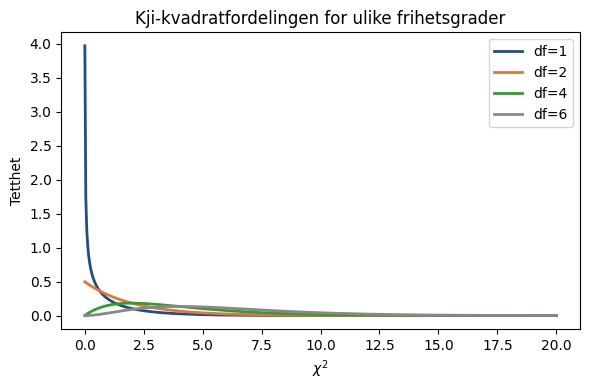

In [2]:
x = np.linspace(0.01, 20, 500)

fig, ax = plt.subplots(figsize=(6, 4))
for df, col in zip([1, 2, 4, 6], [BLUE, ORANGE, "#2ca02c", GRAY]):
    ax.plot(x, stats.chi2.pdf(x, df), color=col, lw=2, label=f"df={df}")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel("Tetthet")
ax.set_title("Kji-kvadratfordelingen for ulike frihetsgrader")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Multinomisk test (godness-of-fit)(kun som eksempel, ikke pensum!!!)

Brukes til å teste om data følger en gitt (teoretisk) fordeling:

$$
H_0: p_1=p_{1,0},\ \dots,\ p_k=p_{k,0} \qquad H_1: \text{minst én sannsynlighet er ulik den angitte.}
$$
$$
\chi^2 = \sum_{i=1}^{k} \frac{(X_i-E_i)^2}{E_i}, \qquad E_i = n\,p_{i,0}, \qquad v = k-1
$$

### Eksempel: er terningen rettferdig?
En terning kastes $120$ ganger. Er terningen rettferdig ($\alpha=0.05$)?

In [3]:
obs_terning = np.array([17, 19, 16, 24, 23, 21])
n_terning = obs_terning.sum()
exp_terning = np.full(6, n_terning / 6)

chi2_t, p_t = stats.chisquare(obs_terning, exp_terning)
df_t = len(obs_terning) - 1
krit_t = stats.chi2.ppf(0.95, df_t)

print(f"n = {n_terning}, forventet pr. side = {exp_terning[0]:.2f}")
print(f"chi2 = {chi2_t:.3f}, df = {df_t}, p = {p_t:.4f}")
print(f"kritisk verdi (0.05, df={df_t}) = {krit_t:.3f}")
print("Konklusjon:", "forkast H0" if chi2_t > krit_t else "behold H0")

n = 120, forventet pr. side = 20.00
chi2 = 2.600, df = 5, p = 0.7614
kritisk verdi (0.05, df=5) = 11.070
Konklusjon: behold H0


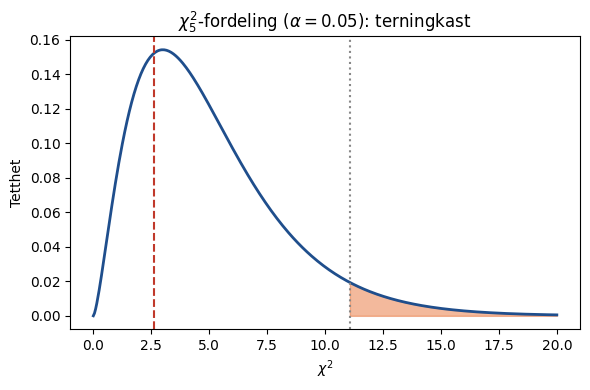

chi2_obs = 2.60 ligger langt til venstre for kritisk verdi 11.07
-> ingenting tyder på at terningen er urettferdig (p > 0.05, behold H0)


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
xx = np.linspace(0.001, 20, 400)
ax.plot(xx, stats.chi2.pdf(xx, df_t), color=BLUE, lw=2)
xr = np.linspace(krit_t, 20, 100)
ax.fill_between(xr, stats.chi2.pdf(xr, df_t), color=ORANGE, alpha=0.5)
ax.axvline(krit_t, color=GRAY, linestyle=":")
ax.axvline(chi2_t, color="#c0392b", linestyle="--")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel("Tetthet")
ax.set_title(rf"$\chi^2_{{{df_t}}}$-fordeling ($\alpha=0.05$): terningkast")
plt.tight_layout()
plt.show()

print(f"chi2_obs = {chi2_t:.2f} ligger langt til venstre for kritisk verdi {krit_t:.2f}")
print("-> ingenting tyder på at terningen er urettferdig (p > 0.05, behold H0)")

### Eksempel: fargevalg på stingsild
$100$ kunder spurt: $42$ foretrekker rød, $31$ blå, $27$ grønn. Er fargene like populære ($\alpha=0.05$)?

In [5]:
obs_farge = np.array([42, 31, 27])
n_farge = obs_farge.sum()
exp_farge = np.full(3, n_farge / 3)

chi2_f, p_f = stats.chisquare(obs_farge, exp_farge)
df_f = len(obs_farge) - 1
krit_f = stats.chi2.ppf(0.95, df_f)

print(f"forventet pr. farge = {exp_farge[0]:.2f}")
print(f"chi2 = {chi2_f:.3f}, df = {df_f}, p = {p_f:.4f}")
print(f"kritisk verdi (0.05, df={df_f}) = {krit_f:.3f}")
print("Konklusjon:", "forkast H0" if chi2_f > krit_f else "behold H0: ingen sikker forskjell i popularitet")

forventet pr. farge = 33.33
chi2 = 3.620, df = 2, p = 0.1637
kritisk verdi (0.05, df=2) = 5.991
Konklusjon: behold H0: ingen sikker forskjell i popularitet


---
## 3. Kjikvadrat uavhengighetstest

To nominale/ordinale variabler ordnet i en $r\times k$-tabell. Under $H_0$ (uavhengighet) er forventet
antall i celle $(i,j)$:

$$
E_{ij} = \frac{\text{Radsum}_i \cdot \text{Kolonnesum}_j}{n}
$$
$$
\chi^2 = \sum_{\text{alle celler}} \frac{(X_{ij}-E_{ij})^2}{E_{ij}}, \qquad v = (r-1)(k-1)
$$

### Eksempel: vegetarianisme og kjønn
$382$ personer spurt om kjønn og vegetarianisme:

In [6]:
tabell_veg = np.array([
    [50, 130],   # Kvinner: Vegetarianer, Ikke vegetarianer
    [35, 167],   # Menn:    Vegetarianer, Ikke vegetarianer
])

chi2_v, p_v, df_v, E_v = stats.chi2_contingency(tabell_veg, correction=False)

print("Observert:\n", tabell_veg)
print("\nForventet (under H0):\n", np.round(E_v, 1))
print(f"\nchi2 = {chi2_v:.3f}, df = {df_v}, p = {p_v:.4f}")
krit_v = stats.chi2.ppf(0.95, df_v)
print(f"kritisk verdi (0.05, df={df_v}) = {krit_v:.3f}")
print("Konklusjon:", "forkast H0: det er en sammenheng mellom kjønn og vegetarianisme"
      if chi2_v > krit_v else "behold H0")

Observert:
 [[ 50 130]
 [ 35 167]]

Forventet (under H0):
 [[ 40.1 139.9]
 [ 44.9 157.1]]

chi2 = 6.009, df = 1, p = 0.0142
kritisk verdi (0.05, df=1) = 3.841
Konklusjon: forkast H0: det er en sammenheng mellom kjønn og vegetarianisme


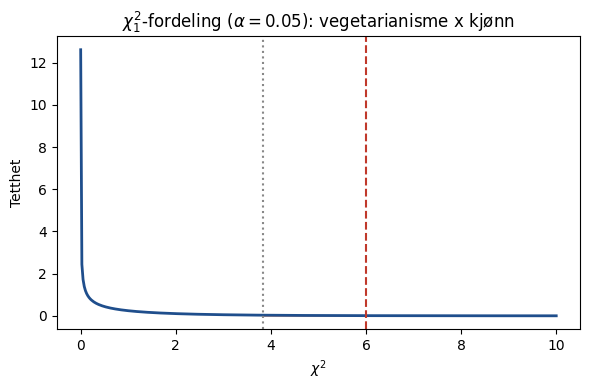

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
xx = np.linspace(0.001, 10, 400)
ax.plot(xx, stats.chi2.pdf(xx, df_v), color=BLUE, lw=2)
xr = np.linspace(krit_v, 10, 100)
ax.fill_between(xr, stats.chi2.pdf(xr, df_v), color=ORANGE, alpha=0.5)
ax.axvline(krit_v, color=GRAY, linestyle=":")
ax.axvline(chi2_v, color="#c0392b", linestyle="--")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel("Tetthet")
ax.set_title(rf"$\chi^2_{{{df_v}}}$-fordeling ($\alpha=0.05$): vegetarianisme x kjønn")
plt.tight_layout()
plt.show()

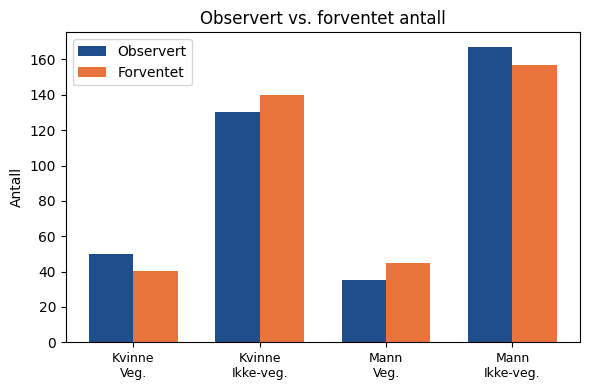

In [8]:
labels = ["Kvinne\nVeg.", "Kvinne\nIkke-veg.", "Mann\nVeg.", "Mann\nIkke-veg."]
obs_flat = tabell_veg.flatten()
exp_flat = E_v.flatten()

xpos = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(xpos - w/2, obs_flat, w, label="Observert", color=BLUE)
ax.bar(xpos + w/2, exp_flat, w, label="Forventet", color=ORANGE)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Antall")
ax.set_title("Observert vs. forventet antall")
ax.legend()
plt.tight_layout()
plt.show()

### Eksempel: kjønn og landsdel --- større tabell ($2\times5$)

In [9]:
tabell_land = np.array([
    [69, 33, 145, 14, 215],   # Kvinne
    [84, 28, 127, 42, 243],   # Mann
])
# kolonner: Nord-Norge, Trøndelag, Vestlandet, Sørlandet, Østlandet

chi2_l, p_l, df_l, E_l = stats.chi2_contingency(tabell_land, correction=False)

print(f"chi2 = {chi2_l:.3f}, df = {df_l}, p = {p_l:.4f}")
krit_l = stats.chi2.ppf(0.95, df_l)
print(f"kritisk verdi (0.05, df={df_l}) = {krit_l:.3f}")
print("Konklusjon:", "forkast H0: kjønnsfordelingen er ulik mellom landsdelene"
      if chi2_l > krit_l else "behold H0")

chi2 = 16.517, df = 4, p = 0.0024
kritisk verdi (0.05, df=4) = 9.488
Konklusjon: forkast H0: kjønnsfordelingen er ulik mellom landsdelene


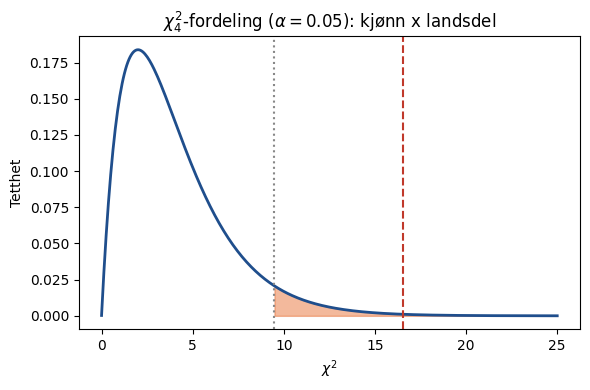

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
xx = np.linspace(0.001, 25, 400)
ax.plot(xx, stats.chi2.pdf(xx, df_l), color=BLUE, lw=2)
xr = np.linspace(krit_l, 25, 100)
ax.fill_between(xr, stats.chi2.pdf(xr, df_l), color=ORANGE, alpha=0.5)
ax.axvline(krit_l, color=GRAY, linestyle=":")
ax.axvline(chi2_l, color="#c0392b", linestyle="--")
ax.set_xlabel(r"$\chi^2$")
ax.set_ylabel("Tetthet")
ax.set_title(rf"$\chi^2_{{{df_l}}}$-fordeling ($\alpha=0.05$): kjønn x landsdel")
plt.tight_layout()
plt.show()

---
## 4. Tommelfingerregel

Maks $20\%$ av cellene kan ha forventet verdi $E_{ij}<5$, og ingen celle skal ha $E_{ij}<1$.
Er ikke dette oppfylt, kan man slå sammen rader/kolonner slik at kategoriene blir færre.

### Eksempel: sammenslåing av karakterkategorier
Karakterene F--A (6 kategorier) krysset mot 5 landsdeler gir mange celler med lavt forventet antall.
Vi slår sammen til 3 grupper: Dårlig (F,E), Bra (D,C), Svært bra (B,A).

In [11]:
# Opprinnelig 6x5-tabell (Master-karakter x Landsdel), hentet fra kildedataene
tabell_master = pd.DataFrame({
    "Nord-Norge": [3, 14, 27, 41, 43, 25],
    "Trondelag":  [0, 4, 5, 22, 21, 9],
    "Vestlandet": [1, 5, 7, 55, 108, 96],
    "Sorlandet":  [0, 4, 14, 17, 15, 6],
    "Ostlandet":  [1, 12, 53, 122, 161, 109],
}, index=["F", "E", "D", "C", "B", "A"])

chi2_m0, p_m0, df_m0, E_m0 = stats.chi2_contingency(tabell_master.values, correction=False)
andel_lav = (E_m0 < 5).mean()
print(f"Opprinnelig {tabell_master.shape[0]}x{tabell_master.shape[1]}-tabell:")
print(f"chi2 = {chi2_m0:.3f}, df = {df_m0}, p = {p_m0:.4g}")
print(f"Andel celler med E<5: {andel_lav*100:.1f}%  (grense: 20%)")

Opprinnelig 6x5-tabell:
chi2 = 96.877, df = 20, p = 4.543e-12
Andel celler med E<5: 23.3%  (grense: 20%)


In [12]:
mapping = {"F": "Darlig", "E": "Darlig", "D": "Bra", "C": "Bra", "B": "Svaert", "A": "Svaert"}
tabell_master_ny = tabell_master.groupby(mapping).sum().reindex(["Darlig", "Bra", "Svaert"])

chi2_m, p_m, df_m, E_m = stats.chi2_contingency(tabell_master_ny.values, correction=False)
andel_lav_ny = (E_m < 5).mean()
print("Etter sammenslaing til 3 kategorier:")
print(tabell_master_ny)
print(f"\nchi2 = {chi2_m:.3f}, df = {df_m}, p = {p_m:.4g}")
print(f"Andel celler med E<5: {andel_lav_ny*100:.1f}%")
print("-> forutsetningen er nå oppfylt, og konklusjonen er den samme: det ER en sammenheng")

Etter sammenslaing til 3 kategorier:
        Nord-Norge  Trondelag  Vestlandet  Sorlandet  Ostlandet
Darlig          17          4           6          4         13
Bra             68         27          62         31        175
Svaert          68         30         204         21        270

chi2 = 68.921, df = 8, p = 8.055e-12
Andel celler med E<5: 13.3%
-> forutsetningen er nå oppfylt, og konklusjonen er den samme: det ER en sammenheng


---
## 5. Effektstørrelse: Cramérs V

$$
V = \sqrt{\dfrac{\chi^2}{n \cdot \min(r-1,\, k-1)}}
$$

$V\in[0,1]$: $0=$ ingen sammenheng, $1=$ perfekt sammenheng. Tolkningen avhenger av frihetsgraden
$\min(r-1,k-1)$ --- **ikke** nødvendigvis den samme frihetsgraden som for selve kjikvadrattesten.

In [13]:
def cramers_v(tabell):
    """Cramers V og tilhørende frihetsgrad (for V) for en r x k-tabell."""
    tabell = np.asarray(tabell)
    chi2, p, df, E = stats.chi2_contingency(tabell, correction=False)
    n = tabell.sum()
    r, k = tabell.shape
    df_v = min(r - 1, k - 1)
    V = np.sqrt(chi2 / (n * df_v))
    return V, df_v, chi2, p

def tolkning(V, df_v):
    grenser = {1: (0.10, 0.30, 0.50), 2: (0.07, 0.21, 0.35),
               3: (0.06, 0.17, 0.29), 4: (0.05, 0.15, 0.25), 5: (0.04, 0.13, 0.22)}
    svak, middels, sterk = grenser.get(df_v, grenser[5])
    if V >= sterk:
        return "sterk effekt"
    elif V >= middels:
        return "middels effekt"
    elif V >= svak:
        return "svak effekt"
    return "ingen/neglisjerbar effekt"

In [14]:
tabell_pepsi = np.array([
    [17, 5],   # Pepsi
    [22, 9],   # Cola
    [9, 4],    # Ingen av dem
])

datasett = {
    "Vegetarianisme x kjonn": tabell_veg,
    "Kjonn x landsdel": tabell_land,
    "Pepsi/Cola x kjonn": tabell_pepsi,
}

rader = []
for navn, tab in datasett.items():
    V, df_v, chi2, p = cramers_v(tab)
    r, k = tab.shape
    df_chi2 = (r - 1) * (k - 1)
    rader.append({"Datasett": navn, "n": tab.sum(), "chi2": round(chi2, 2),
                   "df(chi2)": df_chi2,
                   "p": round(p, 4), "V": round(V, 3), "df(V)": df_v, "Tolkning": tolkning(V, df_v)})

resultat = pd.DataFrame(rader)
resultat

,Datasett,n,chi2,df(chi2),p,V,df(V),Tolkning
0,Vegetarianisme x kjonn,382,6.01,1,0.0142,0.125,1,svak effekt
1,Kjonn x landsdel,1000,16.52,4,0.0024,0.129,1,svak effekt
2,Pepsi/Cola x kjonn,66,0.36,2,0.8362,0.074,1,ingen/neglisjerbar effekt


Alle tre resultatene stemmer med tallene i beamer-presentasjonen:
- **Vegetarianisme × kjønn:** $V=0.125$, mellom svak og middels effekt.
- **Kjønn × landsdel:** $V=0.129$, $v=\min(1,4)=1$ (kjønn har færrest kategorier) $\Rightarrow$ svak effekt --- selv om selve $\chi^2$-testen har $v=4$.
- **Pepsi/Cola × kjønn** ($n=66$): $\chi^2=0.36$, $p=0.836$, $V=0.074$ --- svak/ingen effekt, ikke signifikant.

---
## Oppsummeringstabell

In [15]:
oppsummering = pd.DataFrame([
    {"Test": "Multinomisk (terningkast)", "chi2": round(chi2_t,2), "df": df_t, "p": round(p_t,4), "Konklusjon": "Behold H0"},
    {"Test": "Multinomisk (stingsild)", "chi2": round(chi2_f,2), "df": df_f, "p": round(p_f,4), "Konklusjon": "Behold H0"},
    {"Test": "Uavhengighet (vegetarianisme x kjonn)", "chi2": round(chi2_v,2), "df": df_v, "p": round(p_v,4), "Konklusjon": "Forkast H0"},
    {"Test": "Uavhengighet (kjonn x landsdel)", "chi2": round(chi2_l,2), "df": df_l, "p": round(p_l,4), "Konklusjon": "Forkast H0"},
])
oppsummering

,Test,chi2,df,p,Konklusjon
0,Multinomisk (terningkast),2.60,5,0.7614,Behold H0
1,Multinomisk (stingsild),3.62,2,0.1637,Behold H0
2,Uavhengighet (vegetarianisme x kjonn),6.01,1,0.0142,Forkast H0
3,Uavhengighet (kjonn x landsdel),16.52,4,0.0024,Forkast H0
